# 6 зертханалық жұмыс
## GadgetStore жобасын ықтималдықпен бағалау

**Пән:** АТ-жобаларды басқару. **Тақырып:** Монте-Карло, story points және жоспарлау покері.



Мақсат: 60 ұсақ жұмыс элементін аяқтау мерзімін 10 000 симуляция арқылы бағалау,
P50, P70, P85, P95 квантильдерін алу және детерминистік бағамен салыстыру.
Соңында GadgetStore-дың 10 тарихшасына арналған покердің оқу хаттамасы және тапсырыс берушіге тұжырым беріледі.

**Деректер мәртебесі.** Throughput сандары берілген 6-дәрістің 25-слайдындағы оқу мысалынан алынды.
Бұл GadgetStore трекерінің нақты тарихы емес. Velocity = 11 SP/спринт, покер дауыстары мен 60 элементтік
декомпозиция осы жұмыстың оқу жорамалдары. Адамдармен нақты покер сессиясы өтті деп мәлімделмейді.
Нәтиже шартты сценарийді көрсетеді және жоба мерзіміне нақты міндеттеме ретінде қолданылмайды.

### Іске қосу
Google Colab немесе Python 3.12 ортасында **Restart and Run All** таңдаңыз.
Тек matplotlib керек: қажет болса терминалда `python -m pip install matplotlib==3.10.8` орындаңыз.
Кездейсоқ генератордың seed мәні бекітілген. Кіріс деректер notebook ішінде бар, сыртқы сервер қажет емес.
Графиктер мен есептеу нәтижелері `lab6_results` папкасына жазылады.

In [1]:
from pathlib import Path
from datetime import date, timedelta
from collections import Counter
from statistics import mean, pstdev
import random, math, json, csv, sys
import matplotlib
import matplotlib.pyplot as plt

RESULTS = Path('lab6_results')
RESULTS.mkdir(exist_ok=True)
SEED = 20261008
RUNS = 10_000
THROUGHPUT = [3, 8, 4, 10, 2, 7, 9, 5, 6, 6]
N = 60
START = date(2026, 10, 12)  # жоспарлық бастапқы дүйсенбі
PAUSE_WEEKS = {4, 12}       # нақты оқу күнтізбесі емес, 5-ЗЖ-дағы 2 апта резервінің моделі
PROJECT_WINDOW = 12        # 5-ЗЖ-дағы күнтізбелік жоспар терезесі
VELOCITY = 11              # SP / белсенді екі апталық спринт, өлшенген факт емес
SPRINT_WEEKS = 2

assert len(THROUGHPUT) == 10
assert all(isinstance(v, int) and v >= 0 for v in THROUGHPUT)
assert sum(THROUGHPUT) > 0
assert N > 0 and RUNS == 10_000
print('Python:', sys.version.split()[0], 'Matplotlib:', matplotlib.__version__)
print('Бақылау апталары:', len(THROUGHPUT))
print('Жиыны:', sum(THROUGHPUT), 'элемент; орташа:', mean(THROUGHPUT), 'элемент/белсенді апта')
print('Минимум:', min(THROUGHPUT), 'максимум:', max(THROUGHPUT), 'σ:', round(pstdev(THROUGHPUT), 3))

Python: 3.12.14 Matplotlib: 3.10.8
Бақылау апталары: 10
Жиыны: 60 элемент; орташа: 6 элемент/белсенді апта
Минимум: 2 максимум: 10 σ: 2.449


## 1 Дерек пен өлшем бірліктері

Throughput — бір белсенді аптада **Done** күйіне өткен ұсақ жұмыс элементтерінің саны.
Құрамында тек жазылған код емес, тексерілген нәтижелер есептеледі. Басталған немесе жартылай аяқталған жұмыс есептелмейді.
Дәрістің мысалында күндер берілмегендіктен, тарихи апталарға ойдан күн тағайындалмайды.

Төмендегі 10 тарихша 5-ЗЖ-дағы 10 WBS пакетімен сәйкестендірілді. Әрқайсысында 6 тексерілетін жұмыс элементі бар.
Бұл 60 элемент автоматты түрде бірдей көлемді дегенді білдірмейді: салыстырмалылығы нақты трекерде тексерілуі тиіс.
Қазір толық релиздің оқу моделі бағаланады. Қалған нақты жұмыс саны өлшенген жоқ, дайын кодқа қайтадан толық әзірлеу уақыты жазылмайды.

In [2]:
stories = [
    {'id':'S01','wbs':'1.1','title':'Қабылдаушы ретінде релиз шекарасын және қабылдау шартын көргім келеді', 'sp':3,
     'tasks':['Пайдаланушы сценарийлері','Must-have шекарасы','Қабылдау критерийлері','ФЕТ тізімі','API келісімі','Бекіту жазбасы']},
    {'id':'S02','wbs':'1.2','title':'Сатып алушы ретінде дұрыс бағасы мен суреті бар каталогты көргім келеді', 'sp':5,
     'tasks':['Тұрақты ID тексеруі','Баға өрістерін тексеру','Санат сәйкестігі','Сурет көздерін тіркеу','Seed қайталануын тексеру','Каталог қабылдауы']},
    {'id':'S03','wbs':'1.3','title':'Сатып алушы ретінде тауарды іздеп, сүзіп, толық сипаттамасын ашқым келеді', 'sp':5,
     'tasks':['Іздеу сценарийі','Санат сүзгісі','Сұрыптау сценарийі','Тауар беті','Бос нәтиже күйі','Мобильді тексеру']},
    {'id':'S04','wbs':'2.1','title':'Сатып алушы ретінде себет құрамын өзгертіп, қайта ашқанда сақталуын қалаймын', 'sp':8,
     'tasks':['Тауар қосу','Санын өзгерту','Тауар жою','Себет сақтау','Бүлінген дерек күйі','Себет қабылдауы']},
    {'id':'S05','wbs':'2.2','title':'Сатып алушы ретінде тапсырысымның базада дұрыс сомамен сақталуын қалаймын', 'sp':8,
     'tasks':['Сұрау келісімін тексеру','Тауарды базадан оқу','Серверлік сома','Транзакция тексеруі','ID жауабы','Тапсырыс жазбасы']},
    {'id':'S06','wbs':'2.3','title':'Сатып алушы ретінде форманы толтырып, тапсырыс нөмірін алғым келеді', 'sp':5,
     'tasks':['Аты-жөн өрісі','Телефон тексеруі','Мекенжай өрісі','Қате хабарламасы','Растау экраны','Себетті босату шарты']},
    {'id':'S07','wbs':'2.4','title':'Дүкен өкілі ретінде қате немесе қатар сұраулар қалдықты бұзбауын қалаймын', 'sp':8,
     'tasks':['Жоқ тауар тесті','Қайталанған ID тесті','Қалдықтан артық сан тесті','Жалған сома тесті','Қатар сұрау тесті','Рестарт тесті']},
    {'id':'S08','wbs':'3.1','title':'Тексеруші ретінде жобаны нұсқаулықпен қайта іске қосқым келеді', 'sp':5,
     'tasks':['Node нұсқасы','Іске қосу командасы','Порт конфигурациясы','Health тексеруі','Docker сценарийі','Таза ортадағы іске қосу']},
    {'id':'S09','wbs':'3.2','title':'Жоба иесі ретінде деректерді көшірмеден қалпына келтіргім келеді', 'sp':5,
     'tasks':['Жазуды тоқтату тәртібі','База көшірмесі','Бөлек ортада restore','Жазбалар санын салыстыру','Қалпына келу уақытын өлшеу','Регрессия хаттамасы']},
    {'id':'S10','wbs':'3.3','title':'Қабылдаушы ретінде жобаның негізгі сценарийі мен құжаттарын қабылдағым келеді', 'sp':3,
     'tasks':['Пайдаланушы нұсқаулығы','Іске қосу нұсқаулығы','Көрсетілім сценарийі','Ақаулар тізімі','Қабылдау хаттамасы','Архивті тексеру']}
]
items = [{'id':f"{s['id']}-T{i:02d}", 'story':s['id'], 'wbs':s['wbs'], 'result':t}
         for s in stories for i,t in enumerate(s['tasks'],1)]
TOTAL_SP = sum(s['sp'] for s in stories)
assert len(items) == N == 60 and len(stories) == 10 and TOTAL_SP == 55
for s in stories: print(s['id'], 'WBS',s['wbs'], '|',s['sp'],'SP |',s['title'])
with (RESULTS/'backlog_60.csv').open('w',encoding='utf-8-sig',newline='') as f:
    w=csv.DictWriter(f,fieldnames=list(items[0])); w.writeheader(); w.writerows(items)
with (RESULTS/'throughput_lecture.csv').open('w',encoding='utf-8-sig',newline='') as f:
    w=csv.writer(f); w.writerow(['observation_week','done','source'])
    w.writerows((i,n,'Lecture 6 slide 25, educational example') for i,n in enumerate(THROUGHPUT,1))
print('Жиыны:',len(items),'элемент және',TOTAL_SP,'SP. SP сағатқа айналдырылмайды.')

S01 WBS 1.1 | 3 SP | Қабылдаушы ретінде релиз шекарасын және қабылдау шартын көргім келеді
S02 WBS 1.2 | 5 SP | Сатып алушы ретінде дұрыс бағасы мен суреті бар каталогты көргім келеді
S03 WBS 1.3 | 5 SP | Сатып алушы ретінде тауарды іздеп, сүзіп, толық сипаттамасын ашқым келеді
S04 WBS 2.1 | 8 SP | Сатып алушы ретінде себет құрамын өзгертіп, қайта ашқанда сақталуын қалаймын
S05 WBS 2.2 | 8 SP | Сатып алушы ретінде тапсырысымның базада дұрыс сомамен сақталуын қалаймын
S06 WBS 2.3 | 5 SP | Сатып алушы ретінде форманы толтырып, тапсырыс нөмірін алғым келеді
S07 WBS 2.4 | 8 SP | Дүкен өкілі ретінде қате немесе қатар сұраулар қалдықты бұзбауын қалаймын
S08 WBS 3.1 | 5 SP | Тексеруші ретінде жобаны нұсқаулықпен қайта іске қосқым келеді
S09 WBS 3.2 | 5 SP | Жоба иесі ретінде деректерді көшірмеден қалпына келтіргім келеді
S10 WBS 3.3 | 3 SP | Қабылдаушы ретінде жобаның негізгі сценарийі мен құжаттарын қабылдағым келеді
Жиыны: 60 элемент және 55 SP. SP сағатқа айналдырылмайды.


## 2 Монте-Карло алгоритмі

Әр жүгіртуде тарихи 10 аптадан қайтарып сала отырып, кездейсоқ throughput таңдалады.
Жинақталған нәтиже N-ге жеткенше апта саны өседі. Бұл процедура 10 000 рет қайталанады.
Қайта іріктеу апталардың бір-бірінен тәуелсіз және келешекке өкіл болатынын болжайды.

Квантиль ережесі: сұрыпталған жүгіртулердің `ceil(q × RUNS)` орнындағы бүтін апта.
Сондықтан P85 — жинақталған симуляция үлесі кемінде 85% болатын ең ерте апта.
Бүтін апта себебінен нақты эмпирикалық үлес 85%-дан жоғары болуы мүмкін.

In [3]:
def simulate(history, backlog, runs=10_000, seed=SEED):
    if not history or not all(isinstance(x,int) and x >= 0 for x in history) or not any(history):
        raise ValueError('History must contain nonnegative integer counts and at least one positive count')
    if not isinstance(backlog,int) or backlog <= 0 or runs <= 0:
        raise ValueError('Backlog and runs must be positive')
    rng = random.Random(seed)
    durations = []
    for _ in range(runs):
        done = weeks = 0
        while done < backlog:
            done += rng.choice(history)
            weeks += 1
        durations.append(weeks)
    return durations

durations = simulate(THROUGHPUT,N,RUNS,SEED)
ordered = sorted(durations)
def quantile(values, q):
    ordered_values=sorted(values)
    return ordered_values[math.ceil(q*len(ordered_values))-1]
quantiles = {f'P{int(q*100)}':quantile(durations,q) for q in [.50,.70,.85,.95]}
print('10 000 жүгіртудің квантильдері:',quantiles)
print('Қарапайым бөлу:',N,'/',mean(THROUGHPUT),'=',N/mean(THROUGHPUT),'белсенді апта')
print('Симуляцияның орташа ұзақтығы:',round(mean(durations),3),'белсенді апта')

10 000 жүгіртудің квантильдері: {'P50': 10, 'P70': 11, 'P85': 12, 'P95': 13}
Қарапайым бөлу: 60 / 6 = 10.0 белсенді апта
Симуляцияның орташа ұзақтығы: 10.49 белсенді апта


## 3 Күнтізбеге аудару

Жоспарлық басталу: **12.10.2026, дүйсенбі**. Бір модель қадамы — бір белсенді апта.
5-ЗЖ-дағы 2 апта оқу үзілісі осы сценарийде 4 және 12-күнтізбелік аптаға қойылды.
Белсенді 10 апта міндетті түрде күнтізбелік 12 апта емес: жұмыс 12-аптадағы үзіліске дейін аяқталуы мүмкін.
Аяқталу күні тиісті аптаның жексенбісімен көрсетіледі. Мерекелер мен сессияның нақты күндері расталмаған.

Күту, ревью және үйлестіру нақты throughput тарихында бар болса, оларды қайтадан 15% үстеме ретінде қоспау керек.
Бұл модельде оқу дерегі белсенді апталарға тиесілі деп жорамалданады, екі толық үзіліс бөлек қосылады.

In [4]:
def calendar_week(active_weeks, pauses=PAUSE_WEEKS):
    active = calendar = 0
    while active < active_weeks:
        calendar += 1
        if calendar not in pauses: active += 1
    return calendar
def finish_date(active_weeks):
    return START + timedelta(days=7*calendar_week(active_weeks)-1)
rows=[]
for level,week in quantiles.items():
    share=sum(w <= week for w in durations)/RUNS
    row={'level':level,'active_weeks':week,'calendar_weeks':calendar_week(week),'finish_date':finish_date(week).isoformat(),'empirical_probability':share}
    rows.append(row)
    print(f"{level}: {week} белсенді апта; {row['calendar_weeks']} күнтізбелік апта; {row['finish_date']}; үлес {share:.1%}")
deadline = START + timedelta(days=7*PROJECT_WINDOW-1)
deadline_probability = sum(calendar_week(w)<=PROJECT_WINDOW for w in durations)/RUNS
print(f'5-ЗЖ-дағы {PROJECT_WINDOW} апталық терезе: {deadline}; осы модельде аяқталу үлесі {deadline_probability:.1%}')

P50: 10 белсенді апта; 11 күнтізбелік апта; 2026-12-27; үлес 53.0%
P70: 11 белсенді апта; 13 күнтізбелік апта; 2027-01-10; үлес 78.8%
P85: 12 белсенді апта; 14 күнтізбелік апта; 2027-01-17; үлес 93.0%
P95: 13 белсенді апта; 15 күнтізбелік апта; 2027-01-24; үлес 98.3%
5-ЗЖ-дағы 12 апталық терезе: 2027-01-03; осы модельде аяқталу үлесі 53.0%


## 4 Гистограмма және кумулятивтік қисық

Сол график әр аяқталу ұзақтығының жиілігін көрсетеді. Оң график сол аптаға дейін аяқталған
жүгіртулер үлесін көрсетеді. Көлденең ось — белсенді апта, тік ось — жүгіртулер саны немесе ықтималдық.

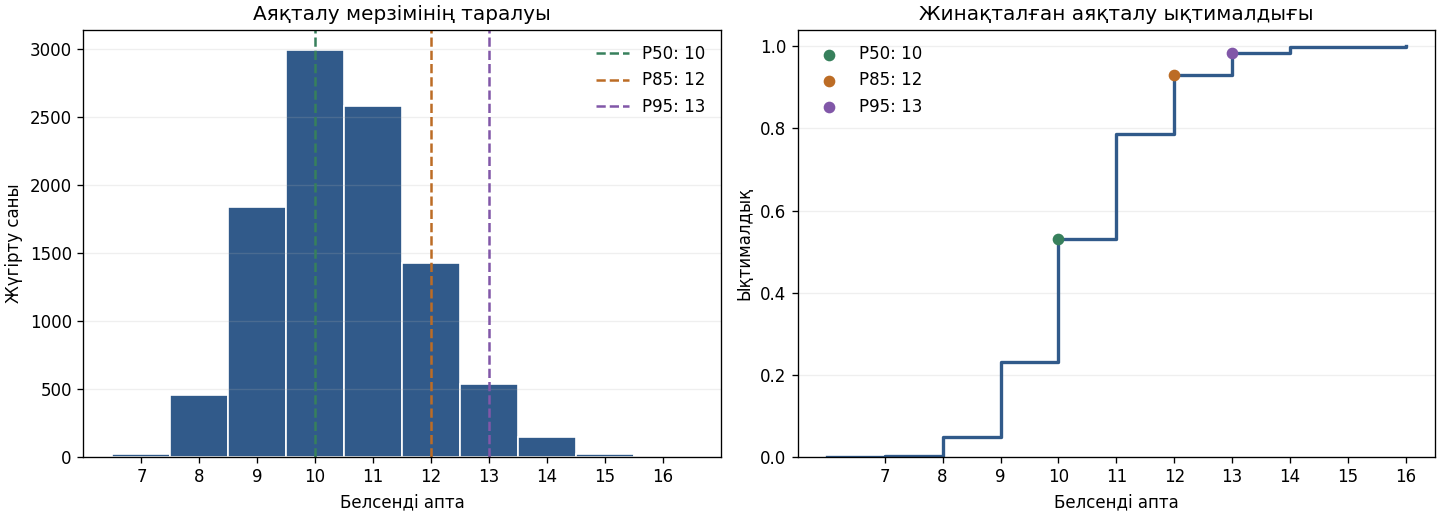

In [5]:
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10})
fig, axes = plt.subplots(1,2,figsize=(12,4.3),layout='constrained')
bins=range(min(durations),max(durations)+2)
axes[0].hist(durations,bins=[x-.5 for x in bins],color='#315A8A',edgecolor='white')
axes[0].set(title='Аяқталу мерзімінің таралуы',xlabel='Белсенді апта',ylabel='Жүгірту саны')
counts=Counter(durations); xs=sorted(counts)
ys=[sum(counts[x] for x in xs if x<=week)/RUNS for week in xs]
axes[1].step([xs[0]-1]+xs,[0]+ys,where='post',color='#315A8A',linewidth=2)
axes[1].set(title='Жинақталған аяқталу ықтималдығы',xlabel='Белсенді апта',ylabel='Ықтималдық',ylim=(0,1.04))
for level,color in [('P50','#37805C'),('P85','#BC6C25'),('P95','#8157A8')]:
    week=quantiles[level]
    axes[0].axvline(week,color=color,linestyle='--',label=f'{level}: {week}')
    axes[1].scatter([week],[sum(w<=week for w in durations)/RUNS],color=color,label=f'{level}: {week}',zorder=3)
for ax in axes:
    ax.set_xticks(xs); ax.grid(axis='y',alpha=.2); ax.legend(frameon=False)
fig.savefig(RESULTS/'monte_carlo.png',dpi=180)
fig.savefig(RESULTS/'monte_carlo.pdf')
plt.show()

## 5 Story points бойынша детерминистік салыстыру

Бэклогтың оқу бағасы: 55 SP. Салыстыру үшін **өлшенбеген жорамал** ретінде 11 SP / екі белсенді апталық
спринт алынды. Бұл 5 спринт немесе 10 белсенді апта береді. Мұнда SP сағатқа айналдырылмайды.
Нақты velocity соңғы аяқталған спринттерден алынуы керек, оны командаға мақсат ретінде тағайындауға болмайды.

10 тарихшадағы 55 SP және 60 ұсақ элемент бір релиз шекарасына жатады, бірақ әртүрлі өлшем бірліктері.
Тарихша өлшемдерінің әркелкілігін ұсақ элементтерге бөлу азайтуы мүмкін, алайда бұл нақты дерекпен расталмаған.

In [6]:
det_sprints=math.ceil(TOTAL_SP/VELOCITY)
det_active=det_sprints*SPRINT_WEEKS
det_calendar=calendar_week(det_active)
det_probability=sum(w<=det_active for w in durations)/RUNS
print(f'Детерминистік: ceil({TOTAL_SP}/{VELOCITY}) = {det_sprints} спринт = {det_active} белсенді апта')
print(f'Күнтізбе: {det_calendar} апта, {finish_date(det_active)}')
print(f'Осы мерзімге дейін аяқталған симуляциялар: {det_probability:.1%}')
print(f'P85 айырмасы: {quantiles["P85"]-det_active} белсенді апта; күнтізбеде {calendar_week(quantiles["P85"])-det_calendar} апта')
print(f'P95 айырмасы: {quantiles["P95"]-det_active} белсенді апта')
print(f'5-ЗЖ терезесінің P85-тен айырмасы: {calendar_week(quantiles["P85"])-PROJECT_WINDOW} күнтізбелік апта')

Детерминистік: ceil(55/11) = 5 спринт = 10 белсенді апта
Күнтізбе: 11 апта, 2026-12-27
Осы мерзімге дейін аяқталған симуляциялар: 53.0%
P85 айырмасы: 2 белсенді апта; күнтізбеде 3 апта
P95 айырмасы: 3 белсенді апта
5-ЗЖ терезесінің P85-тен айырмасы: 2 күнтізбелік апта


### Алшақтық қайдан пайда болады

Детерминистік есеп әр спринт дәл 11 SP береді деп қабылдап, throughput шашырауын жояды.
Ол орташа өнімділікті аяқталу ықтималдығына айналдырмайды. Монте-Карло баяу және жылдам апталардың
әртүрлі тізбектерін сақтайды, сондықтан P85 пен P95 медианадан кейін орналасады.

5-ЗЖ-дағы 80 сағат / 102 сағат capacity есебі ресурстық сәйкестікті ғана көрсетеді.
Ол 12 аптада аяқталу ықтималдығын дәлелдемейді. Осы оқу моделінің өзге дерегі мен 60 элементтік
бөлінуін пайдаланып, алдыңғы жоспарды «нақты қате» деп жариялауға болмайды.
Нақты жоба бойынша қорытындыға жету үшін бірдей scope пен өлшемдегі өз throughput тарихы қажет.

**Дәрістегі арифметикалық сәйкессіздік:** 25-слайд P50=10 және P85=12 апта көрсетеді, айырмасы 2 апта.
26-слайд мәтінінде 3 апта делінген. Бұл жұмыста айырма симуляция нәтижелерінен есептеледі.

## 6 Он тарихшадағы жоспарлау покері

**Мәртебе: оқу мақсатындағы модельдік хаттама. Бұл нақты қатысушылардың дауыс беру жазбасы емес.**
Алдыңғы жұмыста бір орындаушы жорамалы қолданылған. Сондықтан үш адам қатысты деген факт жасалмайды.
Төмендегі A, B, C — интерфейс, сервер және тестілеу тұрғысынан ойластырылған бағалау көзқарастары.

Нақты өткізу тәртібі: қатысушылар тарихша мен Done шартын оқиды; 1, 2, 3, 5, 8, 13 шкаласымен
бағасын жеке таңдайды; бір мезгілде ашады; ең төменгі және жоғарғы бағалардың себептерін талқылайды;
анықталған жұмысты тіркеп, қайта дауыс береді. Консенсус орташа арифметикалық мәнмен ауыстырылмайды.
Нақты сессияда осы кесте қатысушы аты-жөнімен, күнмен және шын дауыстармен ауыстырылады.

In [7]:
poker = [
 ('S01',[2,3,5],3,'Шекараны жазу мен оны қабылдатуды әртүрлі түсіну','Ұмытылған жұмыс: ФЕТ және бекіту дәлелі'),
 ('S02',[3,5,8],5,'Каталогты толтыру мен дерек сапасын тексеру айырмасы','Жасырын тәуелділік: D2 сурет пен дерек шарты'),
 ('S03',[3,5,5],5,'Тек іздеу өрісі немесе толық таңдау сценарийі','Ұмытылған жұмыс: бос нәтиже және мобильді көрініс'),
 ('S04',[5,8,8],8,'Тек қосу немесе қайта ашқанда сақталатын себет','Дайындық түсінігі: бүлінген localStorage және сан шектері'),
 ('S05',[5,8,13],8,'INSERT жеткілікті ме әлде атомарлық өзгеріс керек пе','Жасырын жұмыс: серверлік баға және rollback'),
 ('S06',[3,5,8],5,'Форма көрінісі мен API қатесін көрсету айырмасы','Дайындық түсінігі: сәтті жауаптан кейін ғана себетті тазалау'),
 ('S07',[5,8,13],8,'Кәдімгі тест пен қатар сұрау сценарийінің айырмасы','Ұмытылған жұмыс: соңғы тауарға екі сұрау және жеке тест базасы'),
 ('S08',[3,5,8],5,'Өз компьютерінде іске қосу немесе таза ортада қайталау','Жасырын тәуелділік: Node нұсқасы, порт және Docker қолжетімділігі'),
 ('S09',[3,5,8],5,'Көшірме алу мен restore нәтижесін дәлелдеу айырмасы','Ұмытылған жұмыс: жазбаларды салыстыру және уақыт өлшеу'),
 ('S10',[2,3,5],3,'Файл тапсыру немесе қабылдау хаттамасымен жабу','Жасырын тәуелділік: D3 тексерушінің уақыты')
]
assert [row[2] for row in poker] == [s['sp'] for s in stories]
with (RESULTS/'poker_model.csv').open('w',encoding='utf-8-sig',newline='') as f:
    writer=csv.writer(f)
    writer.writerow(['story','A_model','B_model','C_model','range','consensus_model','disagreement','discovered'])
    for sid,votes,final,reason,found in poker:
        writer.writerow([sid,*votes,max(votes)-min(votes),final,reason,found])
        print(f'{sid}: {votes}; ауқым {max(votes)-min(votes)} SP; модельдік келісім {final} SP')
        print('  Себеп:',reason,'\n  Талқылауда анықталатыны:',found)
print('Модельдік келісім жиыны:',sum(row[2] for row in poker),'SP')

S01: [2, 3, 5]; ауқым 3 SP; модельдік келісім 3 SP
  Себеп: Шекараны жазу мен оны қабылдатуды әртүрлі түсіну 
  Талқылауда анықталатыны: Ұмытылған жұмыс: ФЕТ және бекіту дәлелі
S02: [3, 5, 8]; ауқым 5 SP; модельдік келісім 5 SP
  Себеп: Каталогты толтыру мен дерек сапасын тексеру айырмасы 
  Талқылауда анықталатыны: Жасырын тәуелділік: D2 сурет пен дерек шарты
S03: [3, 5, 5]; ауқым 2 SP; модельдік келісім 5 SP
  Себеп: Тек іздеу өрісі немесе толық таңдау сценарийі 
  Талқылауда анықталатыны: Ұмытылған жұмыс: бос нәтиже және мобильді көрініс
S04: [5, 8, 8]; ауқым 3 SP; модельдік келісім 8 SP
  Себеп: Тек қосу немесе қайта ашқанда сақталатын себет 
  Талқылауда анықталатыны: Дайындық түсінігі: бүлінген localStorage және сан шектері
S05: [5, 8, 13]; ауқым 8 SP; модельдік келісім 8 SP
  Себеп: INSERT жеткілікті ме әлде атомарлық өзгеріс керек пе 
  Талқылауда анықталатыны: Жасырын жұмыс: серверлік баға және rollback
S06: [3, 5, 8]; ауқым 5 SP; модельдік келісім 5 SP
  Себеп: Форма көрінісі

### Талқылаудан шығатын шешімдер

- Тапсырыс API-і бағаны клиенттен қабылдамайды, атомарлық жазба талабын Done шартына қосады.
- Қалпына келтіру пакетіне көшірме алу ғана емес, қалпына келген базаны тексеру кіреді.
- Қабылдаушының уақыты мен каталог деректеріне рұқсат сыртқы тәуелділік ретінде қалады.
- Ең жоғары шашырау S05 пен S07-де: 13 және 5 SP айырмасы жасырын тұтастық жұмысын көрсетеді.
- 13 SP деңгейінде қалған тарихша келесі жоспарлауға дейін бөлінеді. Орташа дауыс алу бағалауды алмастырмайды.

## 7 Жорамалдар, буфер және қайта қарау

Модельдің негізгі шарттары: scope=60 элемент тұрақты; элементтер салыстырмалы; келесі белсенді апталар
дәрістегі үлестіруге ұқсайды; жаңа жұмыс қосылмайды; 4 және 12-апталардан өзге толық үзіліс жоқ.
Bootstrap сирек кездесетін, тарихта болмаған үлкен кідірісті ойлап қоспайды. 10 апта шағын үлгі болып саналады.
Апталардың автокорреляциясы мен оқу жүктемесінің өзгеруі бұл модельде ескерілмеген.

P85–P50 айырмасы мерзім буфері ретінде жеке көрінеді. Ол әр тапсырманың ішіне таратылмайды.
Оның иесі — жоба орындаушысы. Апта сайын қалған элементтер саны, аяқталмаған жұмыстың жасы және
сыртқы тәуелділіктер қайта қаралады. WIP лимиті 1 негізгі пакет болып қалады.

**Қайта қарау күні: 26.10.2026.** Екі нақты аптадағы дерек алғашқы тексеруге ғана жетеді.
Толық эмпирикалық жаңарту үшін 8–12 апталық салыстырмалы тарих жиналады.
Нақты тарих жинақталғанша слайдтағы күндер шартты оқу болжамы ретінде қалады.

In [8]:
# Бэклог 20% ұлғайса, сол үлестіру жағдайындағы сезімталдық.
expanded=simulate(THROUGHPUT,72,RUNS,SEED)
print('60 элемент: P85 =',quantiles['P85'],'белсенді апта')
print('72 элемент: P85 =',quantile(expanded,.85),'белсенді апта')
print('Бұл ықтимал өзгерістің әсері, жаңа жұмыс болады деген факт емес.')

# Қайталанушылық пен мағыналық тексерулер
assert durations == simulate(THROUGHPUT,N,RUNS,SEED)
assert len(durations) == RUNS
assert min(durations) >= math.ceil(N/max(THROUGHPUT))
assert all(a<=b for a,b in zip(quantiles.values(),list(quantiles.values())[1:]))
assert simulate([2],5,3,1) == [3,3,3]
assert calendar_week(3)==3 and calendar_week(4)==5 and calendar_week(10)==11 and calendar_week(11)==13
try:
    simulate([0,0],2,2,1)
    raise AssertionError('Zero-only history must fail')
except ValueError: pass
summary={'seed':SEED,'runs':RUNS,'backlog':N,'story_points':TOTAL_SP,'throughput':THROUGHPUT,
         'data_status':'lecture_example_not_project_history','velocity_status':'assumed_not_measured',
         'velocity':VELOCITY,'start_date':START.isoformat(),'pause_weeks':sorted(PAUSE_WEEKS),
         'quantiles':rows,'det_active':det_active,'det_calendar':det_calendar,
         'det_date':finish_date(det_active).isoformat(),'det_probability':det_probability,
         'lab5_deadline':deadline.isoformat(),'lab5_probability':deadline_probability,
         'expanded_backlog_p85':quantile(expanded,.85)}
(RESULTS/'results.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
print('Тексерулер өтті. Нәтижелер:',RESULTS.resolve())

60 элемент: P85 = 12 белсенді апта
72 элемент: P85 = 14 белсенді апта
Бұл ықтимал өзгерістің әсері, жаңа жұмыс болады деген факт емес.
Тексерулер өтті. Нәтижелер: C:\Users\Yerassil\Desktop\gadgetstore-main\output\lab6\lab6_results


## 8 Тапсырыс берушіге тұжырым

Нақты мерзім квантиль кестесінен алынады. P50 ішкі бағдарды, P85 шартты жоспарлау шегін,
P95 жоғары сақтық шегін көрсетеді. Бұл сандар нақты GadgetStore тарихымен расталмаған.
Бір күнге кепілдік берілмейді. Құрам, scope немесе қолжетімділік өзгерсе, болжам қайта есептеледі.

## Дереккөздер

1. Пайдаланушы ұсынған «6-дәріс. Бағалау (1).pptx»: 23–27-слайдтар — симуляция;
25-слайд — [3, 8, 4, 10, 2, 7, 9, 5, 6, 6]; 13, 15–17-слайдтар — покер және SP;
35–36-слайдтар — мерзім туралы тұжырым; 38–40-слайдтар — зертханалық талаптар.
2. GadgetStore 5-зертханалық жұмысы: 10 WBS пакеті, 80 сағат жұмыс, 102 сағат capacity, 12 апталық жоспар.
3. Жобаның README.md және server.cjs файлдары: релиз шекарасы мен іске асқан мүмкіндіктер.

**Толықтыру қажет нақты деректер:** орындаушының аты-жөні мен тобы; трекердің 8–12 апталық тарихы;
өлшенген velocity; шын покер қатысушыларының дауыстары. Notebook оқу моделін толық есептейді,
бірақ осы деректерді шынайы өлшеу ретінде алмастырмайды.